In [23]:
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from astropy.table import conf
import os
import requests
from pathlib import Path
from tqdm import tqdm
from SpectralAnalysis import *
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.io as pio

# Reading FITS files

In [2]:
DR16 = fits.open("DR16Q_v4.fits")   #original
Shen = fits.open("DR16Q_Shen.fits") #Shen w/ BH masses

In [3]:
data = DR16[1].data
data_mask = (1.2 < data.Z) & (data.Z < 2)
data = data[data_mask]
data2 = Shen[1].data[data_mask]
data2[:10]
print(data.shape)


(285603,)


In [4]:

t = Table.read("DR16Q_v4.fits", hdu = 1)
t2 = Table.read("DR16Q_Shen.fits", hdu = 1)
t["LOGMBH"] = t2["LOGMBH"]

print(t["SDSS_NAME",'LOGMBH'][:10])
print(t2['SDSS_NAME','PLATE', 'LOGMBH'][:10])


    SDSS_NAME            LOGMBH     
------------------ -----------------
000000.15+353104.2 9.073521493837719
000000.33+310325.3 8.985320040245467
000000.36+070350.8 8.065870075869602
000000.36+274356.2 8.673876393640597
000000.45+092308.2  9.54355224492726
000000.45+174625.4 8.642687394735031
000000.47-002703.9 7.434441387709123
000000.57+055630.8 8.665776832933926
000000.62+311944.3 9.397434363897636
000000.66+145828.8  8.96232060613088
    SDSS_NAME      PLATE       LOGMBH     
------------------ ----- -----------------
000000.15+353104.2  7750 9.073521493837719
000000.33+310325.3  7749 8.985320040245467
000000.36+070350.8 11279 8.065870075869602
000000.36+274356.2  7695 8.673876393640597
000000.45+092308.2 11277  9.54355224492726
000000.45+174625.4  7596 8.642687394735031
000000.47-002703.9  4216 7.434441387709123
000000.57+055630.8  8740 8.665776832933926
000000.62+311944.3  7749 9.397434363897636
000000.66+145828.8  6177  8.96232060613088


## Downloading Spectral Data

In [5]:
def download_spectra_from_sdss_names(sdss_names, catalog, save_dir="spectra"):
    os.makedirs(save_dir, exist_ok=True)

    downloaded_files = []
    failed_names = []
    missing_names = []

    def download_one_spectrum(row):
        plate = int(row["PLATE"])
        mjd = int(row["MJD"])
        fiber = int(row["FIBERID"])

        filename = f"spec-{plate}-{mjd}-{fiber:04d}.fits"
        local_path = os.path.join(save_dir, filename)

        if os.path.exists(local_path):
            print("Already exists:", filename)
            return local_path

        urls = [
            (
                "https://data.sdss.org/sas/dr16/eboss/spectro/redux/v5_13_0/"
                f"spectra/lite/{plate}/spec-{plate}-{mjd}-{fiber:04d}.fits"
            ),
            (
                "https://data.sdss.org/sas/dr16/sdss/spectro/redux/v5_13_0/"
                f"spectra/lite/{plate}/spec-{plate}-{mjd}-{fiber:04d}.fits"
            ),
        ]

        for url in urls:
            try:
                r = requests.get(url, timeout=30)
            except requests.RequestException:
                continue

            if r.status_code == 200:
                with open(local_path, "wb") as f:
                    f.write(r.content)

                print("Downloaded:", filename)
                return local_path

        print("Failed:", filename)
        return None

    for name in sdss_names:
        matches = catalog[catalog["SDSS_NAME"] == name]

        if len(matches) == 0:
            print("No match in catalog:", name)
            missing_names.append(name)
            continue

        if len(matches) > 1:
            print("Multiple matches for:", name, "downloading all matches")

        for row in matches:
            path = download_one_spectrum(row)

            if path is not None:
                downloaded_files.append(path)
            else:
                failed_names.append(name)

    return downloaded_files, missing_names, failed_names

## Stack Spectra

In [6]:

def read_dr16_spec(fits_path):
    """Reads one SDSS DR16 spectrum FITS file."""
    with fits.open(fits_path) as hdul:
        data = hdul[1].data

        flux = data["flux"].astype(np.float64)
        loglam = data["loglam"].astype(np.float64)
        model = data["model"].astype(np.float64)
        ivar = data["ivar"].astype(np.float64)

        wavelength = 10**loglam

    return {
        "wavelength": wavelength,
        "flux": flux,
        "model": model,
        "ivar": ivar
    }

def dynamic_stacker(
    z,
    plate,
    mjd,
    fiberid,
    w_start=800.0,
    w_end=3000.0,
    step=1.00015,
    norm_range=(1680.0, 1730.0),
    base_dir="spectra",
):
    """Generates a median composite spectrum from downloaded SDSS spectra."""

    num_pixels = int(np.log(w_end / w_start) / np.log(step)) + 1
    bb = np.arange(num_pixels)
    wgrid = w_start * (step**bb)

    nqsos = len(z)
    sp = np.full((nqsos, num_pixels), np.nan)

    norm_min, norm_max = norm_range

    for i in tqdm(range(nqsos), desc="Stacking Spectra"):
        p_val = int(plate[i])
        m_val = int(mjd[i])
        f_val = int(fiberid[i])

        file_path = Path(base_dir) / f"spec-{p_val}-{m_val}-{f_val:04d}.fits"

        if not file_path.exists():
            print("Missing:", file_path.name)
            continue

        try:
            spec = read_dr16_spec(file_path)

            wave = spec["wavelength"]
            flux = spec["flux"]

            # observed wavelength -> rest-frame wavelength
            rest_wave = wave / (1 + z[i])

            # normalize using chosen rest-frame continuum window
            norm_mask = (rest_wave > norm_min) & (rest_wave < norm_max)

            if not np.any(norm_mask):
                continue

            fnorm = np.nanmedian(flux[norm_mask])

            if fnorm <= 0 or np.isnan(fnorm):
                continue

            flux_norm = flux / fnorm

            # interpolate onto common rest-frame wavelength grid
            flux_interp = np.interp(
                wgrid,
                rest_wave,
                flux_norm,
                left=np.nan,
                right=np.nan
            )

            sp[i] = flux_interp

        except Exception as e:
            print(f"Error processing index {i} ({file_path.name}): {e}")
            continue

    median_spectrum = np.nanmedian(sp, axis=0)

    return wgrid, median_spectrum


def plot_spectrum(spec_data):
    """Plots the extracted SDSS spectrum alongside the pipeline model."""
    wavelength = spec_data["wavelength"].astype(np.float64)
    flux = spec_data["flux"].astype(np.float64)
    model = spec_data["model"].astype(np.float64)
    ivar = spec_data["ivar"].astype(np.float64)

    # Calculate standard deviation (noise) from inverse variance
    # Avoid dividing by zero for masked pixels
    err = np.zeros_like(ivar)
    nonzero = ivar > 0
    err[nonzero] = 1.0 / np.sqrt(ivar[nonzero])

    plt.figure(figsize=(12, 6))

    # Plot the raw observed flux
    plt.plot(
        wavelength,
        flux,
        color="gray",
        alpha=0.5,
        label="Observed Flux (with noise)",
    )

    # Optional: Apply a simple running median filter to smooth the observed flux for visualization
    # (Comment this out if you want to see purely raw data)
    from scipy.ndimage import median_filter

    smoothed_flux = median_filter(flux, size=5)
    plt.plot(
        wavelength,
        smoothed_flux,
        color="black",
        lw=1,
        label="Smoothed Observed Flux",
    )

    # Plot the SDSS pipeline best-fit model
    plt.plot(
        wavelength,
        model,
        color="red",
        lw=1.5,
        label="SDSS Pipeline Fit Model",
    )

    plt.xlabel(r"Observed Wavelength ($\AA$)", fontsize=12)
    plt.ylabel(
        r"Flux ($10^{-17} \text{ erg} \text{ s}^{-1} \text{ cm}^{-2} \mathring{\text{A}}^{-1}$)",
        fontsize=12,
    )
    plt.title("SDSS DR16 Quasar Spectrum", fontsize=14)
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

    # Restrict y-axis limits slightly to ignore extreme bad pixel spikes
    med = np.median(flux)
    std = np.std(flux)
    plt.ylim(med - 2 * std, med + 5 * std)

    plt.show()

## Brightness and Redshift

Text(0.5, 1.0, 'Redshift')

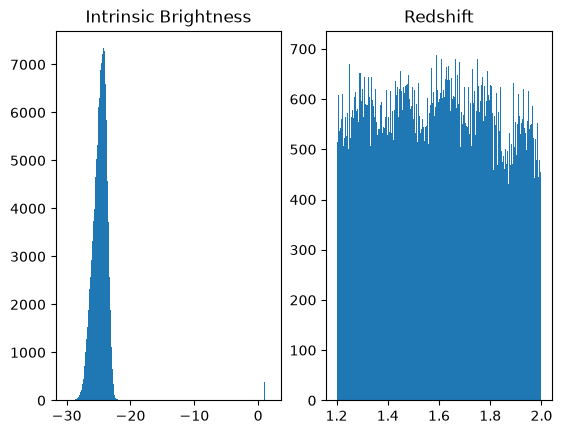

In [7]:
MIgood = data.M_I != -999
Zgood = data.Z != -999

fig,axes = plt.subplots(1,2)
axes[0].hist(data.M_I[MIgood], bins = 500)
axes[0].set_title('Intrinsic Brightness')

axes[1].hist(data.Z[Zgood], bins = 500)
axes[1].set_title('Redshift')

## Bands Magnitude Histogram

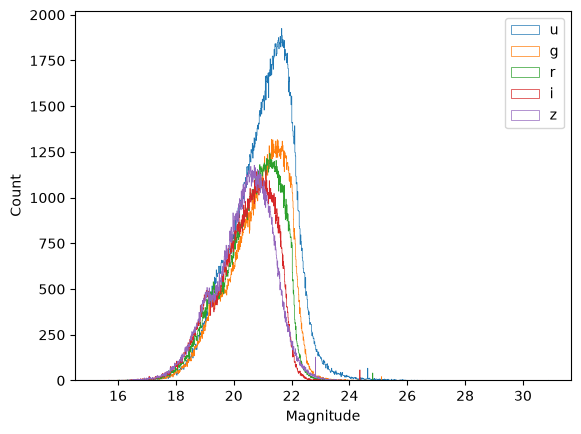

In [8]:
u_mag = data.PSFMAG[:, 0]
g_mag = data.PSFMAG[:, 1]
r_mag = data.PSFMAG[:, 2]
i_mag = data.PSFMAG[:, 3]
z_mag = data.PSFMAG[:, 4]

ug = data.PSFMAG[:, 0] != -9999
gg = data.PSFMAG[:, 1] != -9999
rg = data.PSFMAG[:, 2] != -9999
ig = data.PSFMAG[:, 3] != -9999
zg = data.PSFMAG[:, 4] != -9999

u_mag = u_mag[ug]
g_mag = g_mag[gg]
r_mag = r_mag[rg]
i_mag = i_mag[ig]
z_mag = z_mag[zg]

plt.hist(u_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(g_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(r_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(i_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.hist(z_mag ,bins = 1000, linewidth = 0.5, histtype='step')
plt.legend(['u','g','r','i','z'])
# plt.axis([15, 27.5, 0, 5000])
plt.ylabel('Count')
plt.xlabel('Magnitude')
plt.show()

## Redshift vs Bands

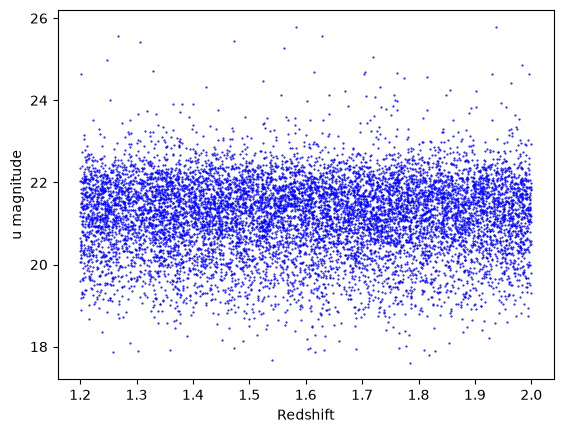

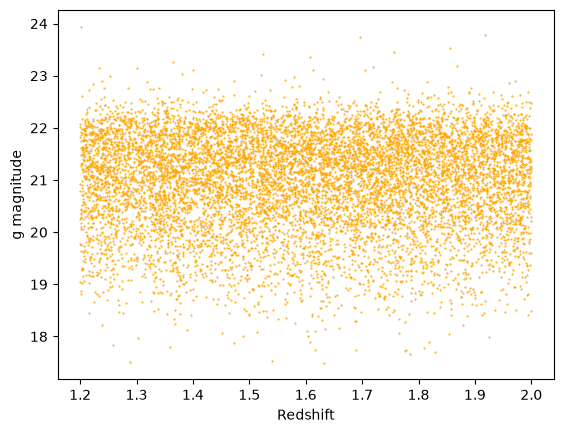

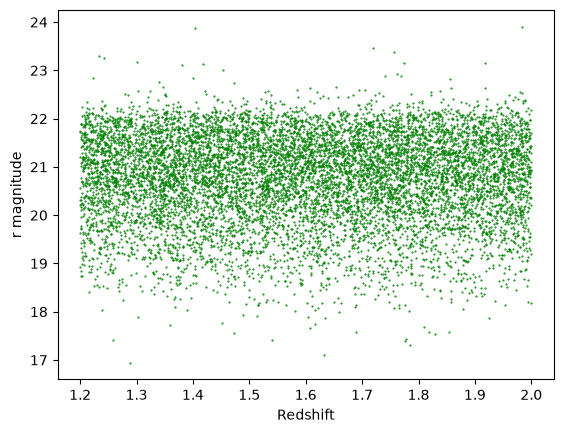

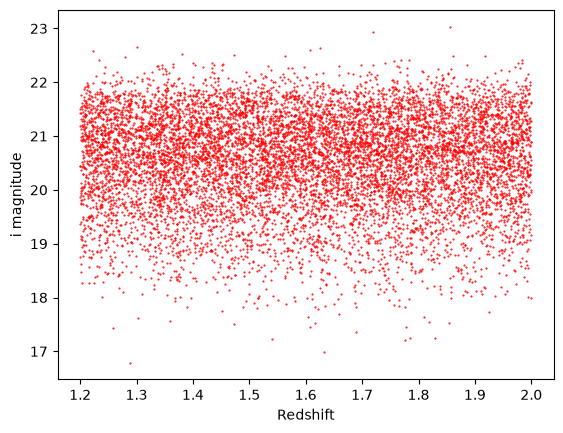

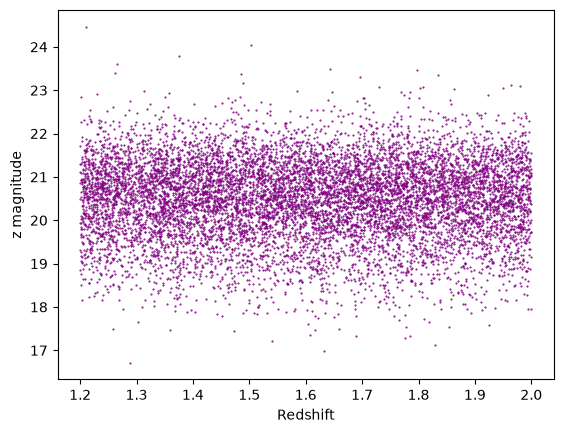

In [9]:
plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], u_mag[i], markersize=1, marker=".", color="blue")
plt.xlabel("Redshift")
plt.ylabel("u magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], g_mag[i], markersize=1, marker=".", color="orange")
plt.xlabel("Redshift")
plt.ylabel("g magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], r_mag[i], markersize=1, marker=".", color="green")
plt.xlabel("Redshift")
plt.ylabel("r magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], i_mag[i], markersize=1, marker=".", color="red")
plt.xlabel("Redshift")
plt.ylabel("i magnitude")
plt.show()

plt.figure()
for i in range(10000):
    plt.plot(data.Z[i], z_mag[i], markersize=1, marker=".", color="purple")
plt.xlabel("Redshift")
plt.ylabel("z magnitude")
plt.show()

## Spectral Analysis Run

Downloading: https://data.sdss.org/sas/dr16/eboss/spectro/redux/v5_13_0/spectra/lite/11277/spec-11277-58450-0705.fits
Successfully saved to ./spec-11277-58450-0705.fits!
spec-11277-58450-0705.fits


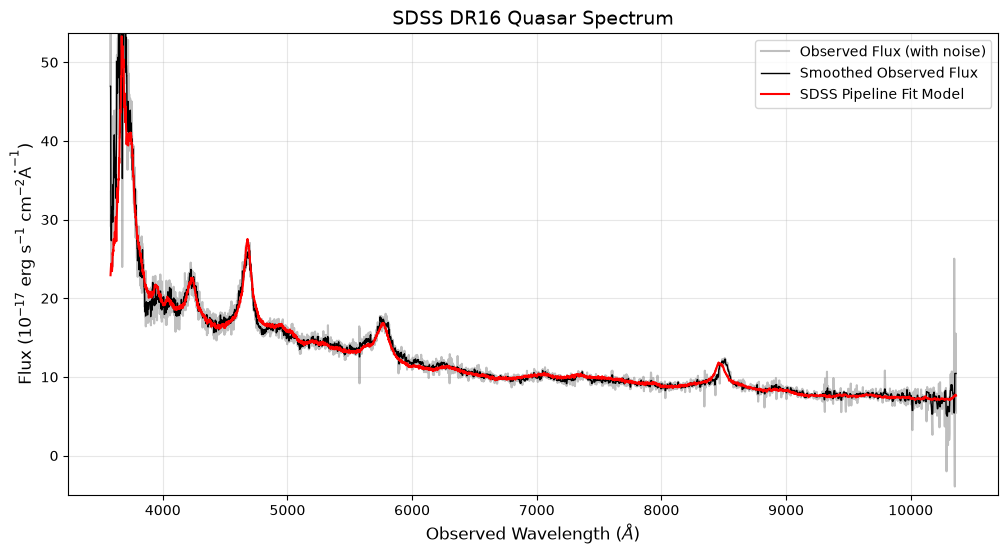

In [10]:
plate = 11277
mjd = 58450  # replace with your target's actual MJD
fiber = 705  # replace with your target's actual Fiber ID

download_sdss_spec(plate, mjd, fiber)
filename = f"spec-{int(plate):04d}-{int(mjd):05d}-{int(fiber):04d}.fits"
print(filename)
try:
    spec_data = read_dr16_spec(filename)
    plot_spectrum(spec_data)
except FileNotFoundError:
    print(
        f"File not found. Please download a DR16 FITS file and update 'fits_file_path'."
    )

## Black Hole Mass Histogram

[8.06587008 8.67387639 9.39743436 ... 8.49576277 8.59796181 9.22546029]


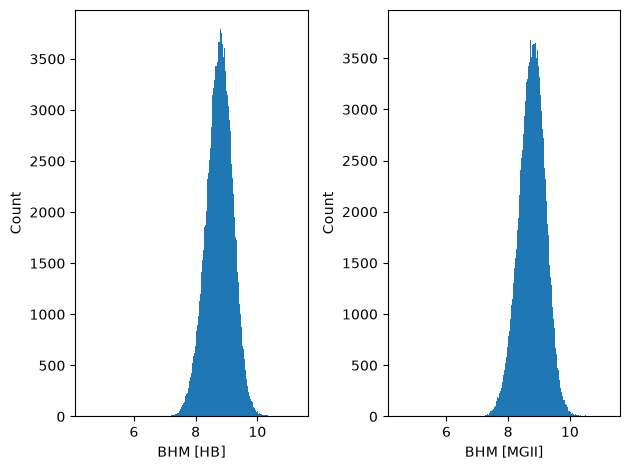

In [11]:
BH_good = data2.LOGMBH != 0
BHM = data2.LOGMBH[BH_good]
BH_MGIIgood = data2.LOGMBH_MGII != 0
print(data2.LOGMBH)
fig, axis = plt.subplots(1,2)

axis[0].hist(BHM, bins = 500)
axis[0].set_xlabel('BHM [HB]')
axis[0].set_ylabel('Count')

axis[1].hist(data2.LOGMBH_MGII[BH_MGIIgood], bins = 500)
axis[1].set_xlabel('BHM [MGII]')
axis[1].set_ylabel('Count')
plt.tight_layout()



In [12]:
print(max(t["LOGMBH"]), min(t['LOGMBH']))


11.471104808291777 0.0


## U-band vs BH Mass

In [13]:
valid_bands = []

for i in range(len(t)):
    if (
        (t["LOGMBH"][i] > 0) and
        (t["PSFMAG"][i, 0] != -9999) and
        (t["PSFMAG"][i, 1] != -9999) and
        (t["PSFMAG"][i, 2] != -9999) and
        (t["PSFMAG"][i, 3] != -9999) and
        (t["PSFMAG"][i, 4] != -9999)):
        valid_bands.append([
            t["LOGMBH"][i],
            t["PSFMAG"][i, 0],
            t["PSFMAG"][i, 1],
            t["PSFMAG"][i, 2],
            t["PSFMAG"][i, 3],
            t["PSFMAG"][i, 4],
            t["SDSS_NAME"][i]])

valid_bands_df = pd.DataFrame(
    valid_bands,
    columns=["LOGMBH", "u_mag", "g_mag", "r_mag", "i_mag", "z_mag", "SDSS_NAME"]
)

In [14]:
g = valid_bands_df["g_mag"]
g_range = g[(g >= 24) & (g <= 26)]
g_range.value_counts().head(100)
top_bad_values_g = g_range.value_counts().head(100).index
clean_df_g = valid_bands_df[~valid_bands_df["g_mag"].isin(top_bad_values_g)]

r = valid_bands_df["r_mag"]
r_range = r[(r >= 24) & (r <= 25)]
r_range.value_counts().head(500)
top_bad_values_r = r_range.value_counts().head(500).index
clean_df_r = valid_bands_df[~valid_bands_df["r_mag"].isin(top_bad_values_r)]

i = valid_bands_df["i_mag"]
i_range = i[(i >= 24) & (i <= 25)]
i_range.value_counts().head(500)
top_bad_values_i = i_range.value_counts().head(500).index
clean_df_i = valid_bands_df[~valid_bands_df["i_mag"].isin(top_bad_values_i)]

z = valid_bands_df["z_mag"]
z_range = z[(z >= 22.5) & (z <= 23)]
z_range.value_counts().head(1000)
top_bad_values_z = z_range.value_counts().head(1000).index
clean_df_z = valid_bands_df[~valid_bands_df["z_mag"].isin(top_bad_values_z)]

combo_mask = ~valid_bands_df["g_mag"].isin(top_bad_values_g) & ~valid_bands_df["r_mag"].isin(top_bad_values_r) & ~valid_bands_df["i_mag"].isin(top_bad_values_i) & ~valid_bands_df["z_mag"].isin(top_bad_values_z)

clean_df_combo = valid_bands_df[combo_mask]


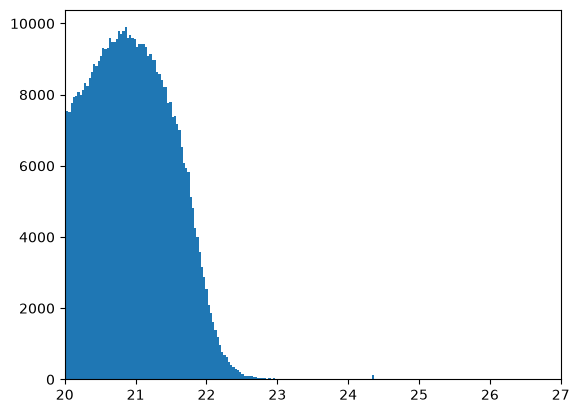

np.int64(359)

In [15]:
plt.hist(valid_bands_df["i_mag"], bins = 500)
plt.xlim([20,27])
plt.show()
np.sum(valid_bands_df["i_mag"] > 23)

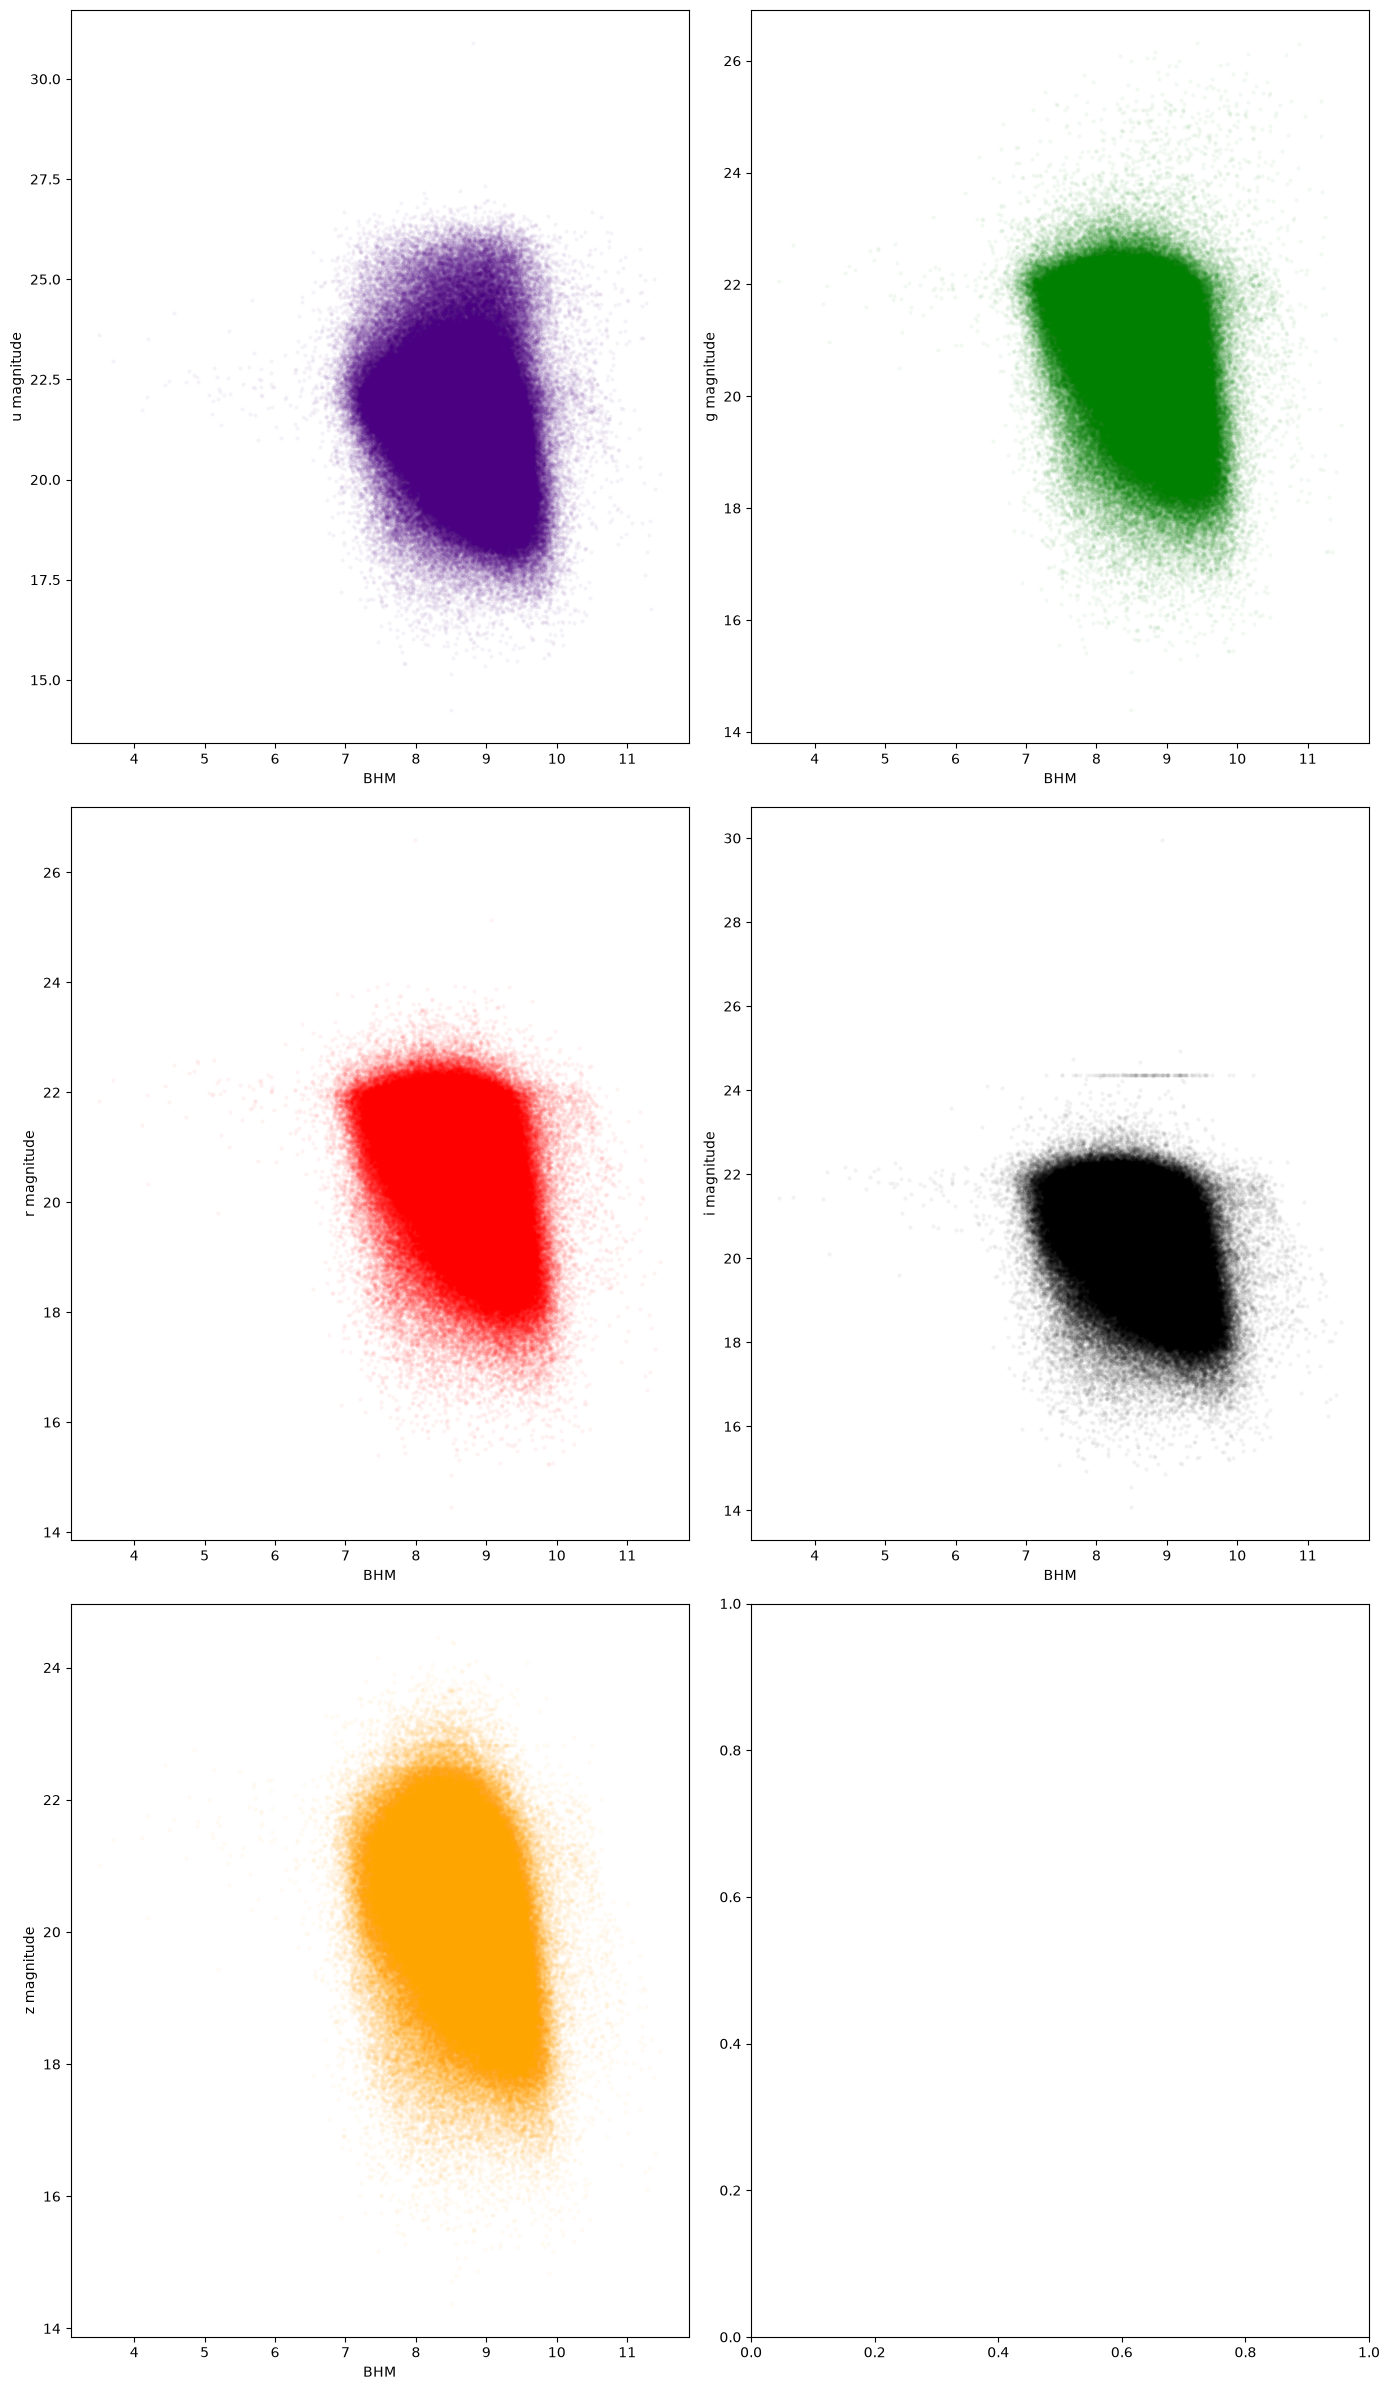

In [16]:
## save this figure as png and send to Monadi


fig, axs = plt.subplots(3, 2, figsize=(14, 24))
axs = axs.ravel()


axs[0].plot(clean_df_combo['LOGMBH'], clean_df_combo['u_mag'], marker=".", color="indigo",ls = '', ms = 6, alpha = 0.05, markeredgewidth=0)
axs[0].set_xlabel("BHM")
axs[0].set_ylabel("u magnitude")

axs[1].plot(clean_df_combo['LOGMBH'], clean_df_combo['g_mag'], marker=".", color="green", ls = '', ms = 6, alpha = 0.05, markeredgewidth=0)
axs[1].set_xlabel("BHM")
axs[1].set_ylabel("g magnitude")

axs[2].plot(clean_df_combo['LOGMBH'], clean_df_combo['r_mag'], marker=".", color="red", ls = '', ms = 6, alpha = 0.05, markeredgewidth=0)
axs[2].set_xlabel("BHM")
axs[2].set_ylabel("r magnitude")

axs[3].plot(valid_bands_df['LOGMBH'], valid_bands_df['i_mag'], marker=".", color="black", ls = '', ms = 6, alpha = 0.05, markeredgewidth=0)
axs[3].set_xlabel("BHM")
axs[3].set_ylabel("i magnitude")

axs[4].plot(clean_df_combo['LOGMBH'], clean_df_combo['z_mag'], marker=".", color="orange", ls = '', ms = 6, alpha = 0.05, markeredgewidth=0)
axs[4].set_xlabel("BHM")
axs[4].set_ylabel("z magnitude")



plt.tight_layout()
plt.savefig("bands_vs_BHM.png", dpi=600, bbox_inches="tight")
plt.show()


BLQ: 1209 objects
Already exists: spec-7848-56959-0047.fits
Already exists: spec-7848-56959-0952.fits
Already exists: spec-7852-56987-0244.fits
Already exists: spec-7862-56984-0439.fits
Already exists: spec-7862-56984-0389.fits
Already exists: spec-7862-56984-0652.fits
Already exists: spec-4217-55478-0717.fits
Already exists: spec-4217-55478-0338.fits
Already exists: spec-7852-56987-0001.fits
Already exists: spec-4217-55478-0775.fits
Already exists: spec-7862-56984-0226.fits
Already exists: spec-7862-56984-0059.fits
Already exists: spec-7863-56975-0707.fits
Already exists: spec-7746-58074-0858.fits
Already exists: spec-7863-56975-0794.fits
Already exists: spec-7694-57359-0434.fits
Already exists: spec-7864-56979-0395.fits
Already exists: spec-7864-56979-0361.fits
Already exists: spec-4536-55857-0877.fits
Already exists: spec-7864-56979-0678.fits
Already exists: spec-7864-56979-0758.fits
Already exists: spec-7865-56955-0570.fits
Already exists: spec-7864-56979-0042.fits
Already exists: 

Stacking Spectra:  58%|███████████▌        | 700/1209 [00:01<00:00, 526.36it/s]

Missing: spec-1877-54464-0586.fits
Missing: spec-770-52282-0470.fits
Missing: spec-770-52282-0173.fits
Missing: spec-770-52282-0137.fits


Stacking Spectra:  81%|████████████████▏   | 979/1209 [00:02<00:00, 541.17it/s]

Missing: spec-1831-54557-0442.fits
Missing: spec-629-52051-0348.fits


...

Missing: spec-2509-54180-0216.fits
Missing: spec-1450-53120-0114.fits
Missing: spec-2023-53851-0126.fits
Missing: spec-1655-53523-0301.fits


Stacking Spectra: 100%|█████████████████████| 394/394 [00:00<00:00, 567.80it/s]


Missing: spec-1823-53886-0313.fits
Missing: spec-355-51788-0201.fits
Missing: spec-367-51997-0229.fits
Missing: spec-726-52226-0198.fits
TRQ: 128 objects
Already exists: spec-4505-55603-0020.fits
Already exists: spec-3757-55508-0976.fits
Already exists: spec-7318-56990-0559.fits
Already exists: spec-7328-56715-0940.fits
Already exists: spec-4903-55927-0462.fits
Already exists: spec-4472-55893-0450.fits
Already exists: spec-5177-56245-0066.fits
Already exists: spec-5155-55946-0777.fits
Already exists: spec-7278-57041-0463.fits
Already exists: spec-5294-55922-0992.fits
Already exists: spec-7516-56782-0705.fits
Already exists: spec-4603-55999-0274.fits
Already exists: spec-3780-55240-0806.fits
Already exists: spec-5775-56009-0354.fits
Already exists: spec-5733-56575-0800.fits
Already exists: spec-7278-57041-0003.fits
Already exists: spec-3766-55213-0878.fits
Already exists: spec-4798-55672-0680.fits
Already exists: spec-5719-56014-0746.fits
Already exists: spec-5720-56602-0046.fits
Alread

Stacking Spectra: 100%|█████████████████████| 128/128 [00:00<00:00, 571.56it/s]

Missing: spec-2508-53875-0111.fits
Missing: spec-847-52426-0554.fits
Missing: spec-918-52404-0260.fits
Missing: spec-922-52426-0160.fits
Missing: spec-366-52017-0036.fits


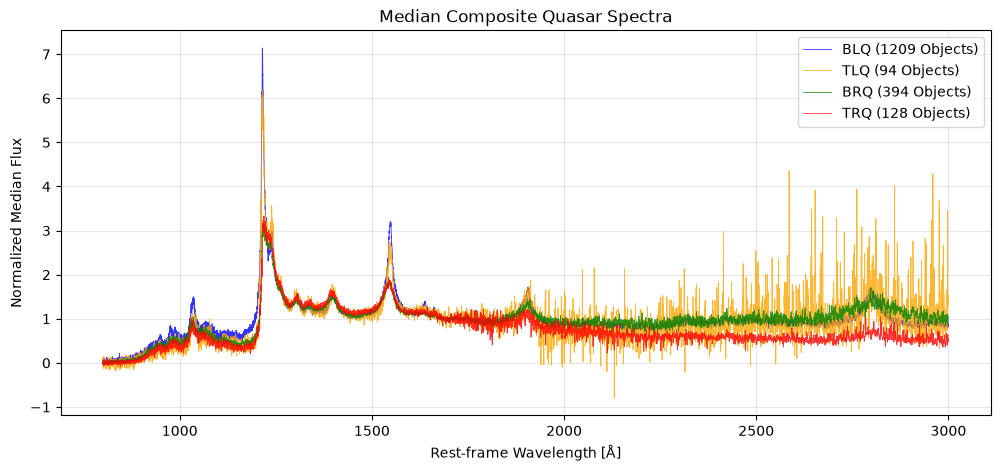

In [17]:
spectra_dir = "/Users/emlilio/Research/Spectra/"
out_dir = "/Users/emlilio/Research/Plots"

groups = {
    "BLQ": {"g_min": 23,   "g_max": 24.5, "mbh_min": 7, "mbh_max": 9},
    "TLQ": {"g_min": 24.5, "g_max": 26,   "mbh_min": 7, "mbh_max": 9},
    "BRQ": {"g_min": 23,   "g_max": 24.5, "mbh_min": 9, "mbh_max": 11},
    "TRQ": {"g_min": 24.5, "g_max": 26,   "mbh_min": 9, "mbh_max": 11},
}

colors = {
    "BLQ": "blue",
    "TLQ": "orange",
    "BRQ": "green",
    "TRQ": "red",
}

stacked_spectra = {}

for label, cuts in groups.items():

    mask = (
        (clean_df_combo["g_mag"] > cuts["g_min"]) &
        (clean_df_combo["g_mag"] < cuts["g_max"]) &
        (clean_df_combo["LOGMBH"] > cuts["mbh_min"]) &
        (clean_df_combo["LOGMBH"] < cuts["mbh_max"])
    )

    sdss_names = clean_df_combo.loc[mask, "SDSS_NAME"].tolist()

    print(f"{label}: {len(sdss_names)} objects")

    dl_files, missing, failed = download_spectra_from_sdss_names(
        sdss_names,
        catalog=t,
        save_dir=spectra_dir
    )

    selected_rows = t[np.isin(t["SDSS_NAME"], sdss_names)]

    wgrid, median_spectrum = dynamic_stacker(
        z=np.array(selected_rows["Z"]),
        plate=np.array(selected_rows["PLATE"]),
        mjd=np.array(selected_rows["MJD"]),
        fiberid=np.array(selected_rows["FIBERID"]),
        base_dir=spectra_dir
    )

    stacked_spectra[label] = {
        "wgrid": wgrid,
        "median_spectrum": median_spectrum,
        "sdss_names": sdss_names,
        "downloaded_files": dl_files,
        "missing": missing,
        "failed": failed,
    }

plt.figure(figsize=(12, 5))

for label, data in stacked_spectra.items():
    plt.plot(
        data["wgrid"],
        data["median_spectrum"],
        alpha = 0.8,
        lw=0.6,
        color=colors[label],
        label=f"{label} ({len(data['sdss_names'])} Objects)"
    )

plt.xlabel("Rest-frame Wavelength [Å]")
plt.ylabel("Normalized Median Flux")
plt.title("Median Composite Quasar Spectra")
plt.legend()
# plt.xlim(wgrid.min(), wgrid.max())
plt.grid(alpha=0.3)

plt.savefig(
    f"{out_dir}/spectra_overlay.png",
    dpi=800,
    bbox_inches="tight"
)

plt.show()

## Dimensional Reduction

In [19]:

# Make color columns
clean_df_combo["u_g"] = clean_df_combo["u_mag"] - clean_df_combo["g_mag"]
clean_df_combo["g_r"] = clean_df_combo["g_mag"] - clean_df_combo["r_mag"]
clean_df_combo["r_i"] = clean_df_combo["r_mag"] - clean_df_combo["i_mag"]
clean_df_combo["i_z"] = clean_df_combo["i_mag"] - clean_df_combo["z_mag"]



In [28]:
pio.renderers.default = "notebook_connected"   # safest option

plot_df_sample = plot_df.sample(n=10000, random_state=1)

fig = px.scatter_3d(
    plot_df_sample,
    x="u_g",
    y="g_r",
    z="r_i",
    labels={
        "u_g": "u - g",
        "g_r": "g - r",
        "r_i": "r - i",
    },
    title="3D Color Space: u-g, g-r, r-i"
)

fig.update_traces(
    marker=dict(
        size=2,
        color="green",
        opacity=0.4
    )
)

fig.update_layout(
    width=900,
    height=800,
    template="plotly_white"
)

fig.show()

In [31]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

features = plot_df[["u_g", "g_r", "r_i"]]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

plot_df_scaled = pd.DataFrame(
    features_scaled,
    columns=["u_g_scaled", "g_r_scaled", "r_i_scaled"]
)

plot_df_scaled_sample = plot_df_scaled.sample(n=10000, random_state=1)

fig = px.scatter_3d(
    plot_df_scaled_sample,
    x="u_g_scaled",
    y="g_r_scaled",
    z="r_i_scaled",
    labels={
        "u_g_scaled": "normalized u - g",
        "g_r_scaled": "normalized g - r",
        "r_i_scaled": "normalized r - i",
    },
    title="Normalized 3D Color Space"
)

fig.update_traces(
    marker=dict(size=2, color="green", opacity=0.4)
)

fig.update_layout(width=900, height=800, template="plotly_white")
fig.show()

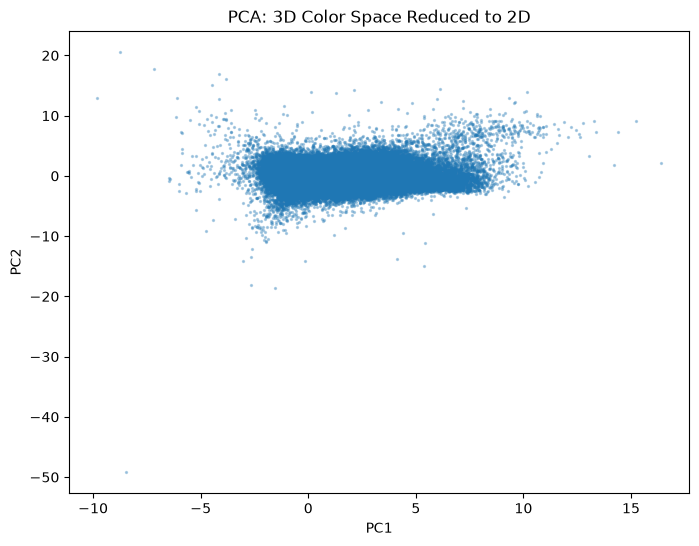

In [29]:

# Choose 3 features for practice
features = clean_df_combo[["u_g", "g_r", "r_i"]].copy()

# Remove bad values if needed
features = features.replace([np.inf, -np.inf], np.nan).dropna()

# Scale features
features_scaled = StandardScaler().fit_transform(features)

# Reduce 3D to 2D
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(features_2d[:, 0], features_2d[:, 1], s=2, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: 3D Color Space Reduced to 2D")
plt.show()

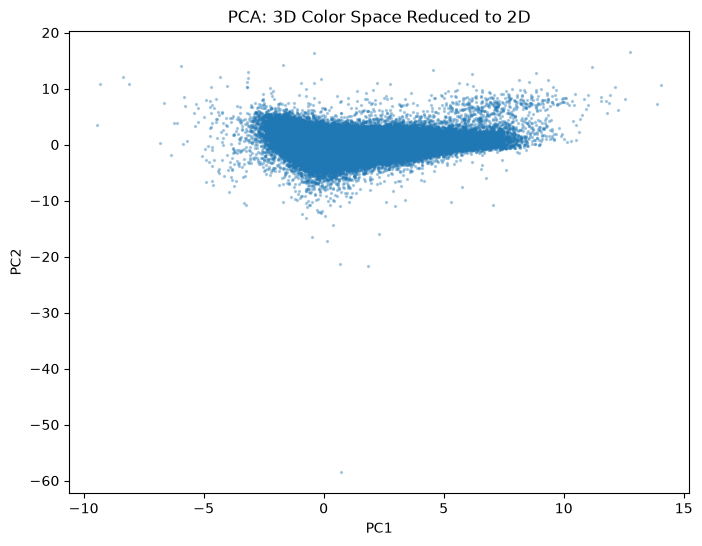

In [37]:
# Choose 3 features for practice
features = clean_df_combo[["u_g", "g_r", "r_i","i_z"]].copy()

# Remove bad values if needed
features = features.replace([np.inf, -np.inf], np.nan).dropna()

# Scale features
features_scaled = StandardScaler().fit_transform(features)

# Reduce 3D to 2D
pca = PCA(n_components=2)
features_2d = pca.fit_transform(features_scaled)

# Reduce 4D to 3D
pca = PCA(n_components=3)
features_3d = pca.fit_transform(features_scaled)

# Put PCA results into a dataframe
pca_df = pd.DataFrame(
    features_3d,
    columns=["PC1", "PC2", "PC3"],
    index=features.index
)

plt.figure(figsize=(8, 6))
plt.scatter(features_2d[:, 0], features_2d[:, 1], s=2, alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: 3D Color Space Reduced to 2D")
plt.show()

In [38]:
# Sample so Plotly does not freeze
pca_df_sample = pca_df.sample(n=min(5000, len(pca_df)), random_state=1)

fig = px.scatter_3d(
    pca_df_sample,
    x="PC1",
    y="PC2",
    z="PC3",
    title="PCA: 4D Color Space Reduced to 3D",
    labels={
        "PC1": "PC1",
        "PC2": "PC2",
        "PC3": "PC3",
    }
)

fig.update_traces(
    marker=dict(
        size=2,
        color="green",
        opacity=0.4
    )
)

fig.update_layout(
    width=900,
    height=800,
    template="plotly_white"
)

fig.show()

## Band Comparison

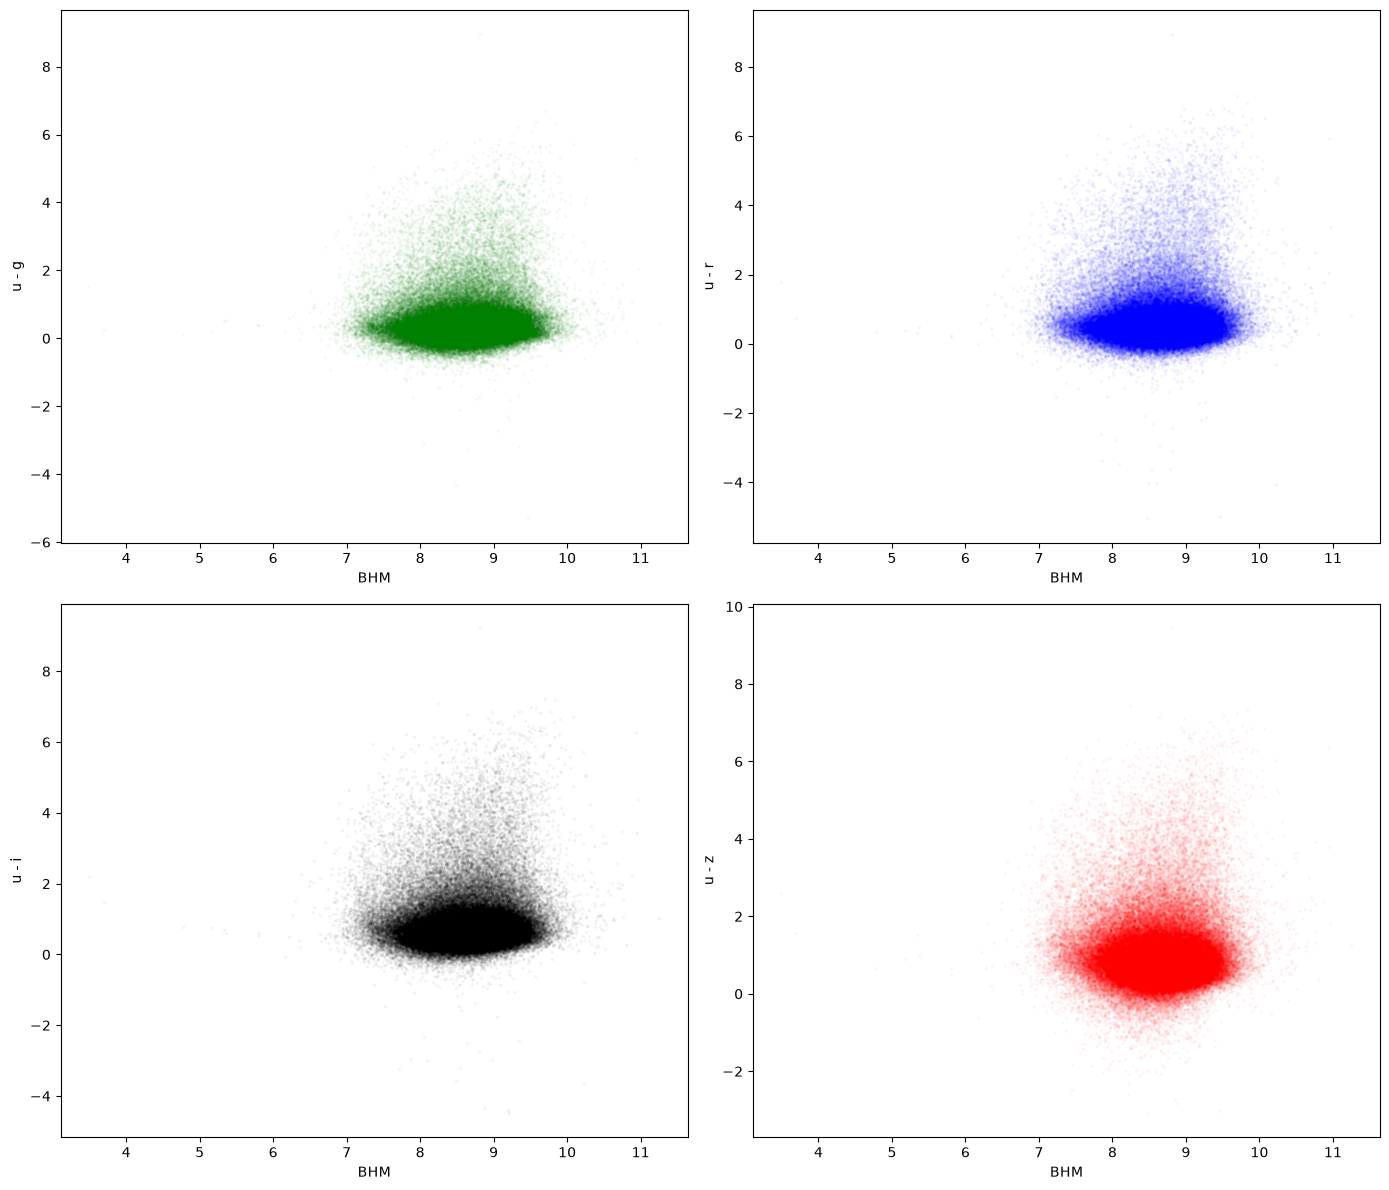

In [20]:
valid_bands_df["u_g"] = valid_bands_df["u_mag"] - valid_bands_df["g_mag"]
valid_bands_df["u_r"] = valid_bands_df["u_mag"] - valid_bands_df["r_mag"]
valid_bands_df["u_i"] = valid_bands_df["u_mag"] - valid_bands_df["i_mag"]
valid_bands_df["u_z"] = valid_bands_df["u_mag"] - valid_bands_df["z_mag"]

fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.ravel()

axs[0].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_g"][:100000], color = 'green', marker=".", ls="", ms=3, alpha=0.03)
axs[0].set_xlabel("BHM")
axs[0].set_ylabel("u - g")

axs[1].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_r"][:100000], color = 'blue', marker=".", ls="", ms=3, alpha=0.03)
axs[1].set_xlabel("BHM")
axs[1].set_ylabel("u - r")

axs[2].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_i"][:100000], color = 'black', marker=".", ls="", ms=3, alpha=0.03)
axs[2].set_xlabel("BHM")
axs[2].set_ylabel("u - i")

axs[3].plot(valid_bands_df["LOGMBH"][:100000], valid_bands_df["u_z"][:100000], color = 'red', marker=".", ls="", ms=3, alpha=0.03)
axs[3].set_xlabel("BHM")
axs[3].set_ylabel("u - z")

plt.tight_layout()
plt.show()

## DBSCAN first run (U-band vs BH mass)

In [21]:
X = np.column_stack([data2.LOGMBH[:200000], u_mag[:200000]])

good = ((X[:, 0] != 0) & (X[:, 1] != 0))

X = X[good] 

X = StandardScaler().fit_transform(X)

#labels = DBSCAN(eps=0.3, min_samples=10).fit_predict(X)
db = DBSCAN(eps=0.3, min_samples=10)
labels = db.fit_predict(X)

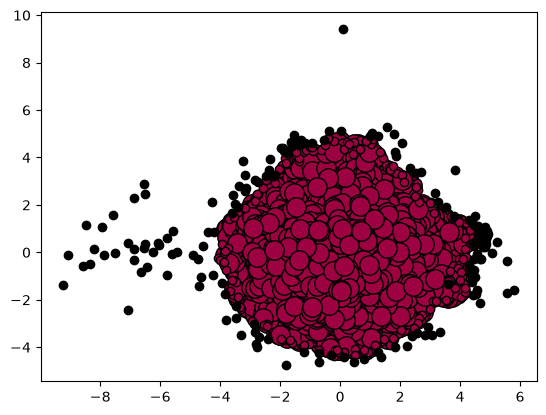

In [22]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=6)

plt.show()

Clusters: 3
Noise points: 4244


Text(0, 0.5, 'i magnitude')

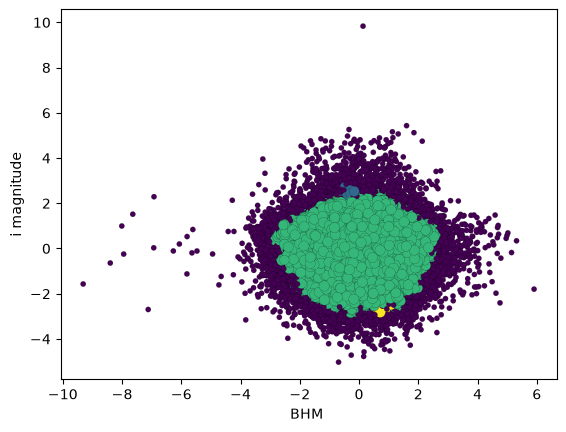

In [23]:
#define the inputs and scale
Y = np.column_stack([data2.LOGMBH[:100000], u_mag[:100000]])
valid = ((Y[:,0] != 0) & (Y[:,1] != 0))
Y = Y[valid]
Y_scaled = StandardScaler(copy = True).fit_transform(Y)

#initiate dbscan
# db = DBSCAN(eps = 0.3,min_samples = 10)
# labels = db.fit_predict(Y_scaled)

#initiate HDBSCAN
db = HDBSCAN(min_cluster_size=50, min_samples=5, copy = True)
labels = db.fit_predict(Y_scaled)

#count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = labels == -1

print("Clusters:", n_clusters)
print("Noise points:", np.sum(noise))

#define sizes
#DBSCAN
# mask = np.zeros_like(labels, dtype = bool) 
# mask[db.core_sample_indices_] = True 
# sizes = np.where(mask, 40, 15)
#HDBSCAN
sizes = 15 + 40 * db.probabilities_

#plot
# plt.figure(figsize=(4, 2), dpi=200)

plt.scatter(Y_scaled[:,0],Y_scaled[:,1],c = labels, s = sizes, edgecolor = 'black', linewidth = 0.1)
plt.xlabel("BHM ")
plt.ylabel("i magnitude")


## X-ray

0
285603


np.float32(2.4061e-15)

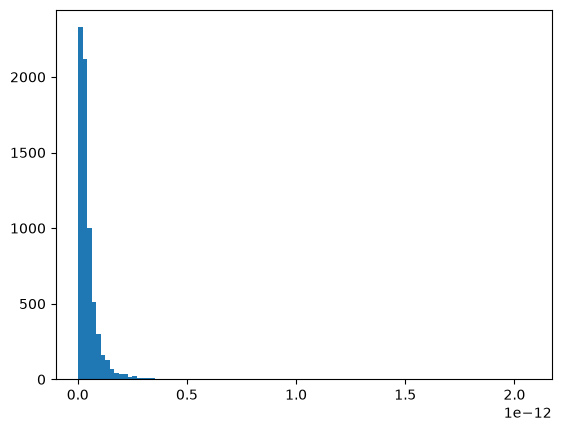

In [24]:
data = DR16[1].data
data_mask = (1.2 < data.Z) & (data.Z < 2)
data = data[data_mask]

total_xray = data.XMM_TOTAL_FLUX
len(total_xray)
max(total_xray)
min(total_xray)
print(np.sum(total_xray == np.inf))
print(len(total_xray))

xray_mask = (total_xray != -1) & (total_xray != np.inf) & (total_xray != 0)
plt.hist(total_xray[xray_mask], bins = 100)
min(total_xray[xray_mask])

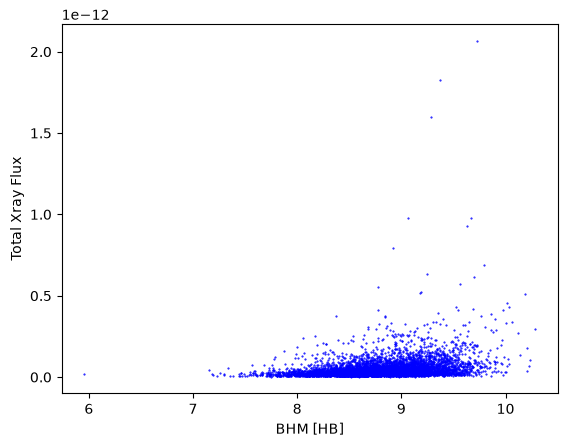

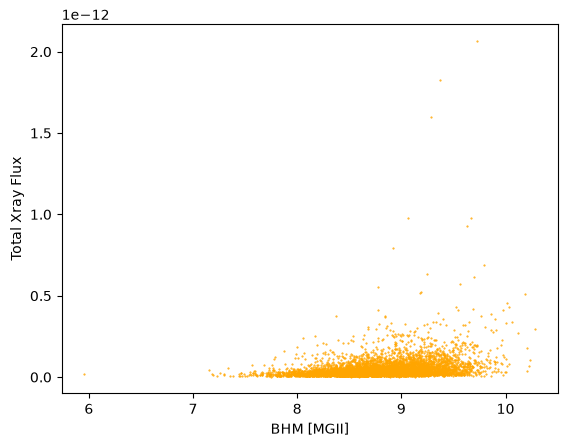

In [25]:
plt.figure()
for i in range(len(data)):
    if data2.LOGMBH[i] != 0 and total_xray[i] != -1 and total_xray[i] != np.inf and total_xray[i] != 0:
        plt.plot(data2.LOGMBH[i], total_xray[i], markersize=1, marker=".", color="blue")
plt.xlabel("BHM [HB]")
plt.ylabel("Total Xray Flux")
plt.show()

plt.figure()
for i in range(len(data)):
    if data2.LOGMBH_MGII[i] != 0 and total_xray[i] != -1 and total_xray[i] != np.inf and total_xray[i] != 0:
        plt.plot(data2.LOGMBH_MGII[i], total_xray[i], markersize=1, marker=".", color="orange")
plt.xlabel("BHM [MGII]")
plt.ylabel("Total Xray Flux")
plt.show()


Clusters: 3
Noise points: 2443


Text(0, 0.5, 'Total Xray Flux')

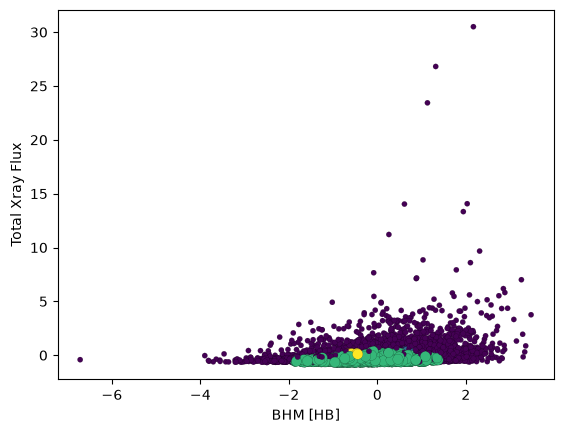

In [26]:
#define the inputs and scale
Y = np.column_stack([data2.LOGMBH[:len(total_xray)], total_xray])
valid = ((Y[:,0] != 0) & (Y[:,1] != -1) & (Y[:,1] != np.inf) & (Y[:,1] != 0))
Y = Y[valid]
Y_scaled = StandardScaler(copy = True).fit_transform(Y)

#initiate dbscan
# db = DBSCAN(eps = 0.3,min_samples = 10)
# labels = db.fit_predict(Y_scaled)

#initiate HDBSCAN
db = HDBSCAN(min_cluster_size=30, min_samples=10, copy = True)
labels = db.fit_predict(Y_scaled)

#count clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
noise = labels == -1

print("Clusters:", n_clusters)
print("Noise points:", np.sum(noise))

#define sizes
#DBSCAN
# mask = np.zeros_like(labels, dtype = bool) 
# mask[db.core_sample_indices_] = True 
# sizes = np.where(mask, 40, 15)
#HDBSCAN
sizes = 15 + 40 * db.probabilities_

#plot
# plt.figure(figsize=(4, 2), dpi=200)

plt.scatter(Y_scaled[:,0],Y_scaled[:,1],c = labels, s = sizes, edgecolor = 'black', linewidth = 0.1)
plt.xlabel("BHM [HB]")
plt.ylabel("Total Xray Flux")


## 3D attempt

/var/folders/0x/tff67vxd02vc2x9f8gxwj3800000gn/T/ipykernel_7020/3475093883.py:24: RuntimeWarning: invalid value encountered in log10
  y_arr_log = np.log10(y_arr)


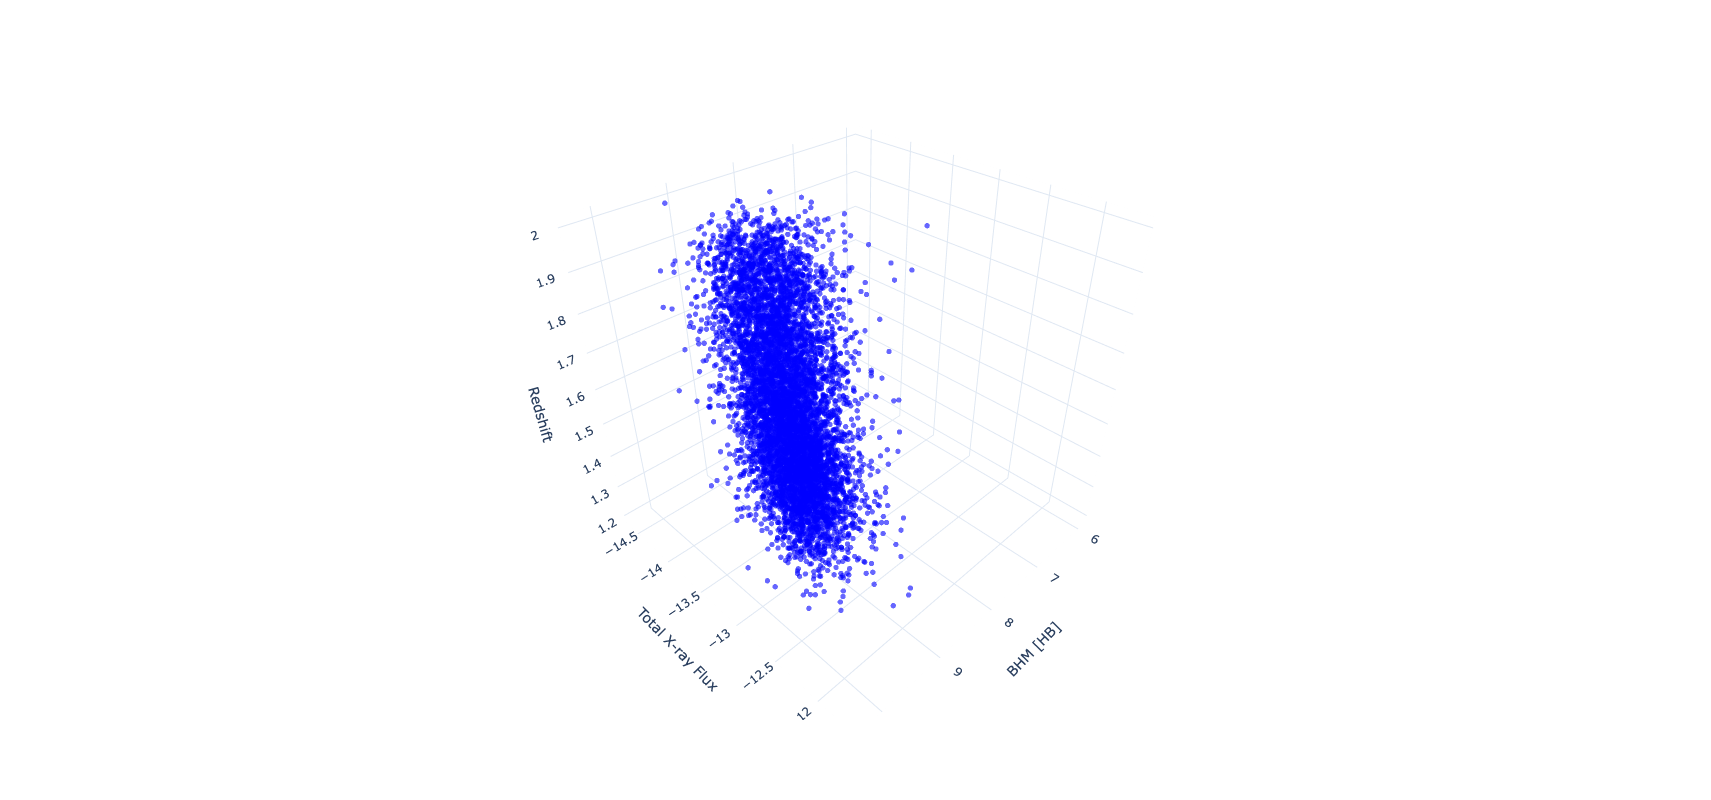

In [27]:
#%matplotlib tk

# fig = plt.figure(figsize=(9, 8)) 
# ax = fig.add_subplot(projection='3d')
# ax.set_box_aspect((1, 1, 1))


# for i in range(500000):
#     if data2.LOGMBH[i] != 0 and total_xray[i] != -1 and total_xray[i] != np.inf and total_xray[i] != 0 and data.Z[i] != -999:
#         ax.plot(data2.LOGMBH[i], total_xray[i], data.Z[i], markersize=10, marker=".", color="blue")
# ax.set_xlabel("BHM [HB]", labelpad=15, fontsize = 11)
# ax.set_ylabel("Total X-ray Flux ($10^{-13}$)", labelpad=15, fontsize=11)
# ax.set_zlabel("Redshift", labelpad=15, fontsize = 11)
# ax.set_box_aspect(None, zoom=0.85) 

# plt.tight_layout() 
# plt.show()

# Slow and Laggy ^^^^

x_arr = np.array(data2.LOGMBH)
y_arr = np.array(total_xray)
z_arr = np.array(data.Z)
y_arr_log = np.log10(y_arr)

mask = ((x_arr != 0) & (y_arr != -1) & (y_arr != np.inf) & (y_arr != 0) & (z_arr != -999) & (z_arr < 4) & (z_arr > 0))

plot_df = pd.DataFrame({'BHM': x_arr[mask],'Flux': y_arr_log[mask],'Redshift': z_arr[mask]})

fig = px.scatter_3d(plot_df, x='BHM', y='Flux', z='Redshift',labels={'BHM': 'BHM [HB]', 'Flux': 'Total X-ray Flux','Redshift': 'Redshift'})

fig.update_traces(marker=dict(size=3, color='blue', opacity=0.6))
fig.update_layout(width=900, height=800, template='plotly_white')

fig.show()

In [ ]:
plot_df['logFlux'] = np.log10(y_arr[mask])
features = plot_df[['BHM', 'logFlux', 'Redshift']]

# features_scaled = StandardScaler().fit_transform(features)

db = HDBSCAN(min_cluster_size=10, min_samples=10, copy=True)

labels = db.fit_predict(features_scaled)

plot_df['cluster_num'] = labels
plot_df['cluster'] = labels.astype(str)

fig = px.scatter_3d(plot_df, x='BHM', y='logFlux', z='Redshift', color='cluster',
labels={'BHM': 'BHM [HB]',
        'logFlux': 'logFlux [log10]',
        'Redshift': 'Redshift',
        'cluster': 'HDBSCAN Cluster'})
fig.update_traces(marker=dict(size=3, opacity=0.6))
fig.update_layout(width=900, height=800, template='plotly_white')

fig.show()


# Outlier Detection method notes

Three methods of detection exist to classify outliers and normal points
## Supervised:
A supervised detection method is one in which a normal classification is defined by an individual, that class is then used to compare other points, if they do not fit the description they are labeled outliers. One can make several classes however this method struggles with inbalance. Most data will have very few outliers in comparison to the normal points. This leaves our classifyer with very little information to learn about outliers. A couple ways to mitigate this are through oversampling or creating artificial outliers.

## Unsupervised:
An unsupervised detection method works with clusters. Data point may make more than one cluster which we can consider to be normal. Any points that are far isolated from a group can then be considered an outlier. This is the kind of method DBSCAN is. The weaknesses of this method is many of these points could be noise instead of actual outliers. Also it is energy intensive due to having to identify all the normal points before you can get to the outliers which is what we care about, having to process seemingly unimportant information is anapealing because its computationally expensive.

## Semi_Supervised
Semi_supervised detection is a combination of the two, again it struggles with low outlier availibility


# 3D Plotting Guide

## 1. Convert arrays to numpy arrays
This makes our data easier to work with and more efficient.<br>
```python
NumPy_array = **np.array**(Regular_array)
```

## 2. Mask
Not every item in our data set contains valuable information, Filter those out by creating a mask which collects only the indexes with useful data. In this case mask is an array containing true and false values, where the true indexes are those which satified the internal conditions.<br>
```python
mask = (NumPy_array != value & etc...)
```

## 3. Create a Pandas Data Frame
The dataframe provides the layout for our data. Here plot_df is a table where the columns are the arrays in which they're listed and the rows are the data.<br>
```python
plot_df = **pd.DataFrame**({'Name': NumPy_array[mask], etc...})
```

## 4. Plotting
We create our figure using the plotting function **px.scatter_3d**, Within the function we write in our data frame (plot_df), we assign the axis to each column by name, and we add labels to each axis.<br>
```python
fig = px.scatter_3d(plot_df, x='C_1', y='C_2', z='C_3', labels={'C_1': 'Axis_label', etc...})
```
## 5. Customize Plot
To alter the visuals on our figure use functions **update_traces** and **update_layout**
```python
fig.update_traces(marker=dict(size=3, color='blue', opacity=0.6))
fig.update_layout(width=900, height=800, template='plotly_white')
```
## 6. Display the Figure
```python
fig.show()
```

## 7. Define Features for HBDSCAN
HBDSCAN requires our parameters to be defined under features.<br>
```python
features = plot_df[['C_1', 'C_2', 'C_3']]
```
<br>

**Note:** Keep an eye on the orders of magnitude, if on axis is much great apply log scaling to that data set with **np.log10**.<br>
```python
plot_df['logFlux'] = np.log10(plot_df['Flux'])
features = plot_df[['BHM', 'logFlux', 'Redshift']]
```

## 8. Scaling
Because HBDSCAN works with distance we need to scale our features, this makes sure that the difference in scale between the measurments doesn't create bias.<br>
```python
features_scaled = StandardScaler().fit_transform(features)
```

## 9. Create HDBSCAN Model
Initiate HDBSCAN, assign model values and create your labels.<br>
```python
db = HDBSCAN(min_cluster_size=20, min_samples=10, copy=True)

labels = db.fit_predict(features_scaled)
```

## 10. HDBSCAN to DataFrame
We must add our labels result from HBDSCAN to our dataframe to use it in plotly.<br>
```python
plot_df['cluster_num'] = labels
plot_df['cluster'] = labels.astype(str)
```

## 11. Plotly with HBDSCAN
To add HBDSCAN to our figure, add these parameters into the previous **px.scatter_3d** function:<br>
```python
color='cluster', size='strength',
labels={'C_1': 'Axis label 1',
        'C_2': 'Axis label 2',
        'C_3': 'Axis label 3',
        'cluster': 'HDBSCAN Cluster',
        'strength': 'Membership Strength'}
```

for each cluster stack and "average" their spectra to view pattern?
